In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet
from prophet.plot import plot_cross_validation_metric
from prophet.diagnostics import cross_validation, performance_metrics

from sklearn.metrics import mean_absolute_error

from itertools import product

import warnings
warnings.filterwarnings('ignore')

/Users/oksjjj/coding/skada/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
plt.rcParams['figure.figsize'] = (10, 7.5)
plt.rcParams['axes.grid'] = False

Source: https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=1810000201

In [3]:
df = pd.read_csv('../data/monthly_avg_retail_price_food_canada.csv')
df.head()

,REF_DATE,GEO,DGUID,Products,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1995-01,Canada,2016A000011124,"Round steak, 1 kilogram",Dollars,81,units,0,v735165,1.1,10.17,NaN,NaN,NaN,2
1,1995-02,Canada,2016A000011124,"Round steak, 1 kilogram",Dollars,81,units,0,v735165,1.1,10.29,NaN,NaN,NaN,2
2,1995-03,Canada,2016A000011124,"Round steak, 1 kilogram",Dollars,81,units,0,v735165,1.1,10.12,NaN,NaN,NaN,2
3,1995-04,Canada,2016A000011124,"Round steak, 1 kilogram",Dollars,81,units,0,v735165,1.1,10.38,NaN,NaN,NaN,2
4,1995-05,Canada,2016A000011124,"Round steak, 1 kilogram",Dollars,81,units,0,v735165,1.1,10.00,NaN,NaN,NaN,2


In [4]:
df.shape

(16166, 15)

In [5]:
df = df[df['Products'] == 'Round steak, 1 kilogram']
df.head()

,REF_DATE,GEO,DGUID,Products,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1995-01,Canada,2016A000011124,"Round steak, 1 kilogram",Dollars,81,units,0,v735165,1.1,10.17,NaN,NaN,NaN,2
1,1995-02,Canada,2016A000011124,"Round steak, 1 kilogram",Dollars,81,units,0,v735165,1.1,10.29,NaN,NaN,NaN,2
2,1995-03,Canada,2016A000011124,"Round steak, 1 kilogram",Dollars,81,units,0,v735165,1.1,10.12,NaN,NaN,NaN,2
3,1995-04,Canada,2016A000011124,"Round steak, 1 kilogram",Dollars,81,units,0,v735165,1.1,10.38,NaN,NaN,NaN,2
4,1995-05,Canada,2016A000011124,"Round steak, 1 kilogram",Dollars,81,units,0,v735165,1.1,10.00,NaN,NaN,NaN,2


In [6]:
df.columns

Index(['REF_DATE', 'GEO', 'DGUID', 'Products', 'UOM', 'UOM_ID',
       'SCALAR_FACTOR', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'VALUE', 'STATUS',
       'SYMBOL', 'TERMINATED', 'DECIMALS'],
      dtype='str')

In [7]:
cols_to_drop = ['GEO', 'DGUID', 'Products', 'UOM', 'UOM_ID',
       'SCALAR_FACTOR', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'STATUS',
       'SYMBOL', 'TERMINATED', 'DECIMALS']

df = df.drop(cols_to_drop, axis=1)
df.head()

,REF_DATE,VALUE
0,1995-01,10.17
1,1995-02,10.29
2,1995-03,10.12
3,1995-04,10.38
4,1995-05,10.00


In [8]:
df.shape

(323, 2)

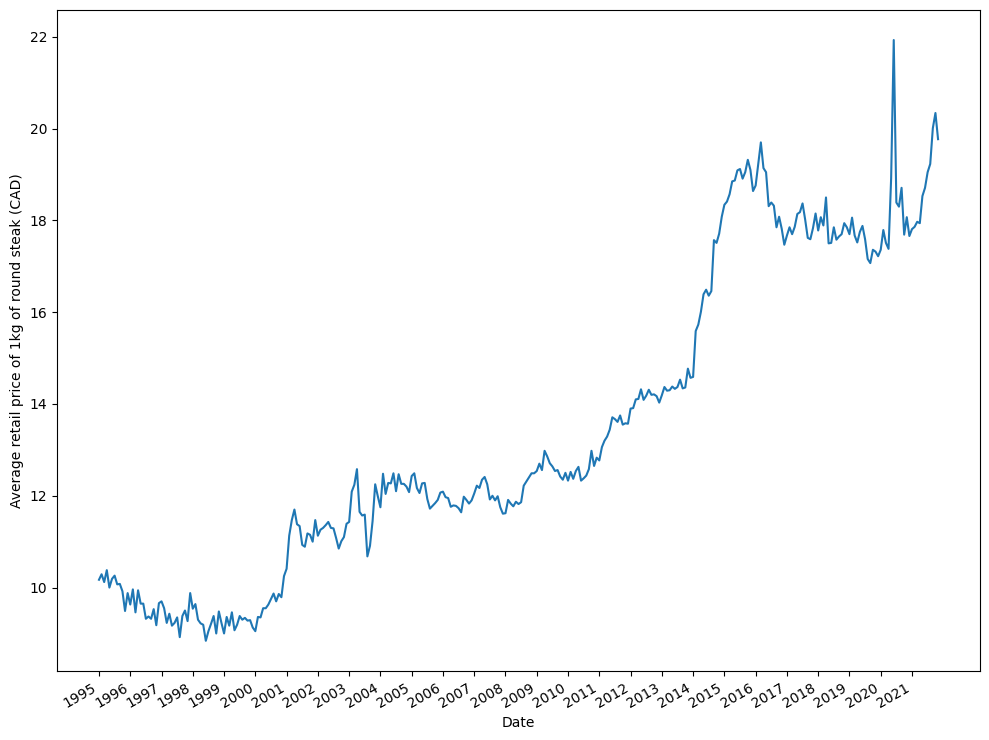

In [9]:
fig, ax = plt.subplots()

ax.plot(df['VALUE'])
ax.set_xlabel('Date')
ax.set_ylabel('Average retail price of 1kg of round steak (CAD)')

plt.xticks(np.arange(0, 322, 12), np.arange(1995, 2022, 1))

fig.autofmt_xdate()
plt.tight_layout()

In [10]:
df.columns = ['ds', 'y']

In [11]:
from pandas.tseries.offsets import MonthEnd

df['ds'] = pd.to_datetime(df['ds']) + MonthEnd(1)

df.head()

,ds,y
0,1995-01-31,10.17
1,1995-02-28,10.29
2,1995-03-31,10.12
3,1995-04-30,10.38
4,1995-05-31,10.00


In [12]:
train = df[:-36]
test = df[-36:]

train.tail()

,ds,y
282,2018-07-31,17.85
283,2018-08-31,17.58
284,2018-09-30,17.65
285,2018-10-31,17.70
286,2018-11-30,17.94


In [14]:
param_grid = {
    'changepoint_prior_scale': [0.01, 0.1, 1.0],
    'seasonality_prior_scale': [0.1, 1.0, 10.0]
}

params = [dict(zip(param_grid.keys(), v)) for v in product(*param_grid.values())]

mses = []

cutoffs = pd.date_range(start='2000-01-31', end=train['ds'].max() - pd.Timedelta('365 days'), freq='36ME')

for param in params:
    m = Prophet(**param)
    m.fit(train)
    
    df_cv = cross_validation(model=m, horizon='365 days', cutoffs=cutoffs)
    df_p = performance_metrics(df_cv, rolling_window=1)
    mses.append(df_p['mse'].values[0])
    
tuning_results = pd.DataFrame(params)
tuning_results['mse'] = mses

05:38:59 - cmdstanpy - INFO - Chain [1] start processing
05:38:59 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 0/6 [00:00<?, ?it/s]05:38:59 - cmdstanpy - INFO - Chain [1] start processing
05:38:59 - cmdstanpy - INFO - Chain [1] done processing
 17%|█▋        | 1/6 [00:00<00:00,  7.38it/s]05:38:59 - cmdstanpy - INFO - Chain [1] start processing
05:38:59 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 2/6 [00:00<00:00,  5.56it/s]05:38:59 - cmdstanpy - INFO - Chain [1] start processing
05:38:59 - cmdstanpy - INFO - Chain [1] done processing
05:38:59 - cmdstanpy - INFO - Chain [1] start processing
05:38:59 - cmdstanpy - INFO - Chain [1] done processing
05:38:59 - cmdstanpy - INFO - Chain [1] start processing
05:38:59 - cmdstanpy - INFO - Chain [1] done processing
 83%|████████▎ | 5/6 [00:00<00:00, 13.18it/s]05:38:59 - cmdstanpy - INFO - Chain [1] start processing
05:38:59 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 6/6 [00:00<00:00, 12

In [15]:
best_params = params[np.argmin(mses)]
print(best_params)

{'changepoint_prior_scale': 1.0, 'seasonality_prior_scale': 10.0}


In [16]:
m = Prophet(**best_params)
m.fit(train)

05:39:51 - cmdstanpy - INFO - Chain [1] start processing
05:39:51 - cmdstanpy - INFO - Chain [1] done processing


In [17]:
future = m.make_future_dataframe(periods=36, freq='ME')

In [18]:
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)

,ds,yhat,yhat_lower,yhat_upper
311,2020-12-31,19.191480,17.370621,20.948254
312,2021-01-31,19.185978,17.299290,20.931638
313,2021-02-28,19.521075,17.476030,21.435730
314,2021-03-31,19.444957,17.251093,21.436296
315,2021-04-30,19.569989,17.289558,21.793851
316,2021-05-31,19.513949,17.083330,21.753144
317,2021-06-30,19.440420,16.896225,21.913930
318,2021-07-31,19.402241,16.759619,22.010835
319,2021-08-31,19.389062,16.549101,22.116152
320,2021-09-30,19.398574,16.383981,22.119404


In [19]:
test[['yhat', 'yhat_lower', 'yhat_upper']] = forecast[['yhat', 'yhat_lower', 'yhat_upper']]
test.head()

,ds,y,yhat,yhat_lower,yhat_upper
287,2018-12-31,17.85,18.586882,17.961180,19.273966
288,2019-01-31,17.70,18.572571,17.879929,19.214401
289,2019-02-28,18.06,18.751356,18.087788,19.446869
290,2019-03-31,17.67,18.779519,18.097645,19.461302
291,2019-04-30,17.52,19.032962,18.395282,19.721819


In [20]:
test['Baseline'] = train['y'].iloc[-1]
test.head()

,ds,y,yhat,yhat_lower,yhat_upper,Baseline
287,2018-12-31,17.85,18.586882,17.961180,19.273966,17.94
288,2019-01-31,17.70,18.572571,17.879929,19.214401,17.94
289,2019-02-28,18.06,18.751356,18.087788,19.446869,17.94
290,2019-03-31,17.67,18.779519,18.097645,19.461302,17.94
291,2019-04-30,17.52,19.032962,18.395282,19.721819,17.94


In [21]:
baseline_mae = mean_absolute_error(test['y'], test['Baseline'])
prophet_mae = mean_absolute_error(test['y'], test['yhat'])

print(prophet_mae)
print(baseline_mae)

1.1572586968918155
0.6816666666666671


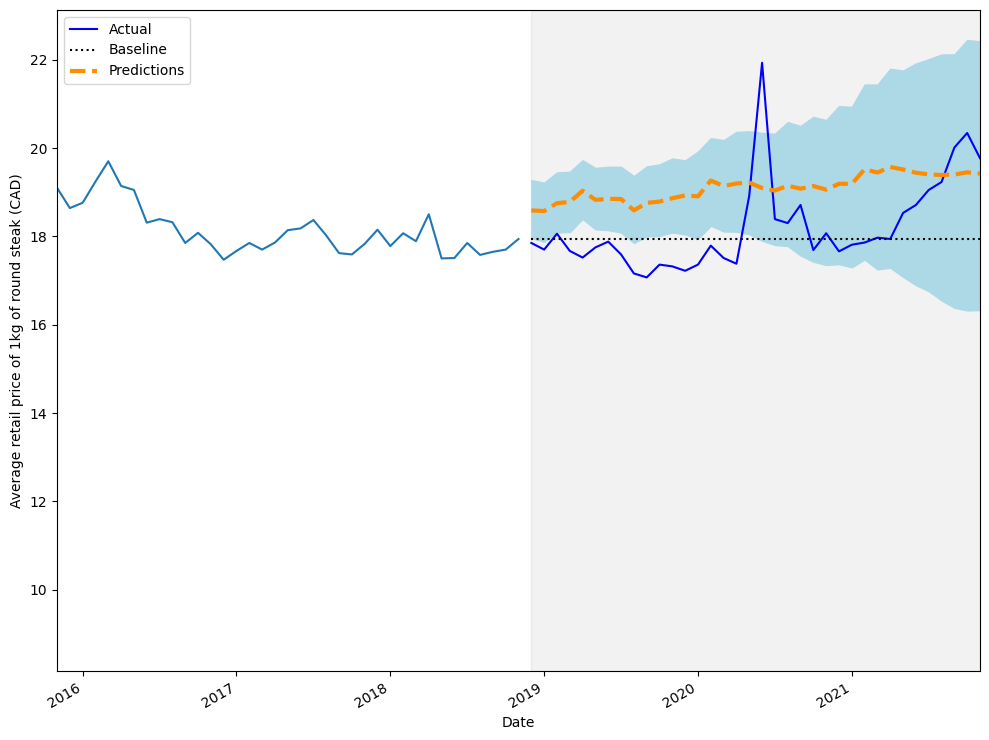

In [23]:
fig, ax = plt.subplots()

ax.plot(train['y'])
ax.plot(test['y'], 'b-', label='Actual')
ax.plot(test['Baseline'], 'k:', label='Baseline')
ax.plot(test['yhat'], color='darkorange', ls='--', lw=3, label='Predictions')

ax.set_xlabel('Date')
ax.set_ylabel('Average retail price of 1kg of round steak (CAD)')

ax.axvspan(287, 322, color='#808080', alpha=0.1)

ax.legend(loc='best')

plt.xticks(np.arange(0, 322, 12), np.arange(1995, 2022, 1))
plt.fill_between(x=test.index, y1=test['yhat_lower'], y2=test['yhat_upper'], color='lightblue')
plt.xlim(250, 322)

fig.autofmt_xdate()
plt.tight_layout()

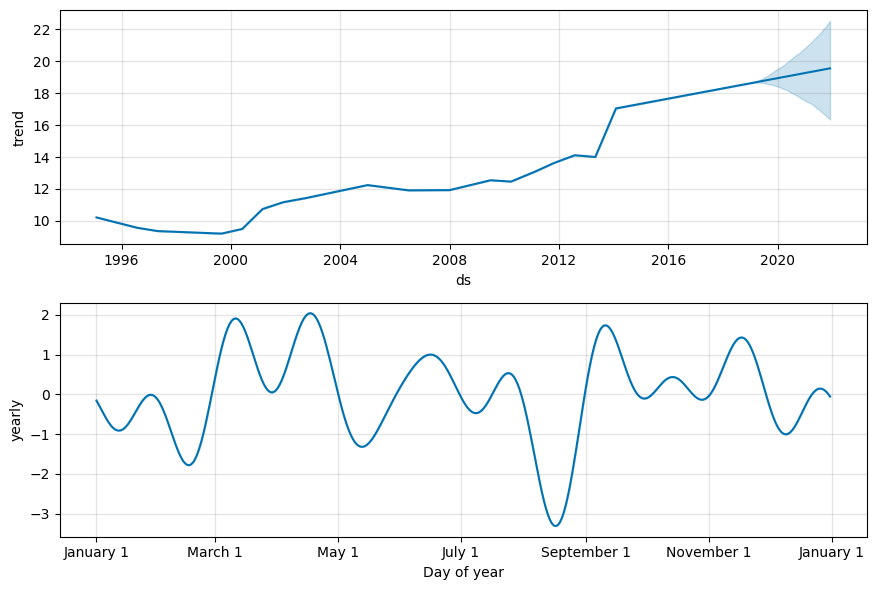

In [25]:
prophet_components_fig = m.plot_components(forecast)

## SARIMA 

In [26]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from tqdm import tqdm
from typing import Union

In [27]:
ad_fuller_result = adfuller(df['y'])

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: 0.31276604677391195
p-value: 0.9779226633224507


In [28]:
y_diff = np.diff(df['y'], n=1)

ad_fuller_result = adfuller(y_diff)

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -16.784744900608814
p-value: 1.2558701587332352e-29


In [29]:
def optimize_SARIMAX(endog: Union[pd.Series, list], exog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:
    
    results = []
    
    for order in tqdm(order_list):
        try: 
            model = SARIMAX(
                endog,
                exog,
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        results.append([order, model.aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [30]:
ps = range(1, 4, 1)
qs = range(1, 4, 1)
Ps = range(1, 4, 1)
Qs = range(1, 4, 1)

order_list = list(product(ps, qs, Ps, Qs))

d = 1
D = 0
s = 12

In [31]:
SARIMA_result_df = optimize_SARIMAX(train['y'], None, order_list, d, D, s)
SARIMA_result_df

  6%|▌         | 5/81 [00:02<00:41,  1.84it/s]/Users/oksjjj/coding/skada/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
  9%|▊         | 7/81 [00:04<00:50,  1.48it/s]/Users/oksjjj/coding/skada/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
 10%|▉         | 8/81 [00:05<00:54,  1.34it/s]/Users/oksjjj/coding/skada/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
 12%|█▏        | 10/81 [00:06<00:48,  1.45it/s]/Users/oksjjj/coding/skada/.venv/lib/python3.11/site-packages/statsmodels/base/mode

,"(p,q,P,Q)",AIC
0,"(2, 3, 1, 1)",59.502974
1,"(2, 3, 1, 2)",60.476955
2,"(3, 2, 1, 1)",60.641443
3,"(2, 3, 2, 1)",60.867651
4,"(3, 2, 2, 1)",61.562658
...,...,...
75,"(3, 3, 1, 3)",78.717319
76,"(3, 3, 1, 2)",79.322033
77,"(3, 3, 1, 1)",79.334220
78,"(3, 3, 3, 3)",79.469590


In [32]:
SARIMA_model = SARIMAX(train['y'], order=(2,1,3), seasonal_order=(1,0,1,12), simple_differencing=False)
SARIMA_model_fit = SARIMA_model.fit(disp=False)

print(SARIMA_model_fit.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  287
Model:             SARIMAX(2, 1, 3)x(1, 0, [1], 12)   Log Likelihood                 -21.751
Date:                              Fri, 26 Jun 2026   AIC                             59.503
Time:                                      05:42:44   BIC                             88.751
Sample:                                           0   HQIC                            71.226
                                              - 287                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.2327      0.044     28.028      0.000       1.147       1.319
ar.L2         -0.92

/Users/oksjjj/coding/skada/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


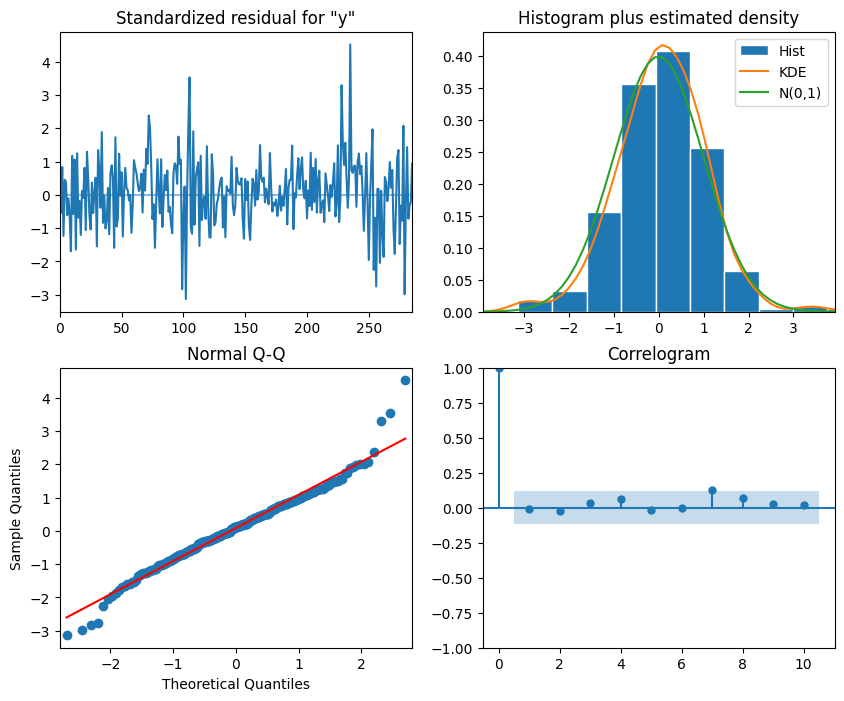

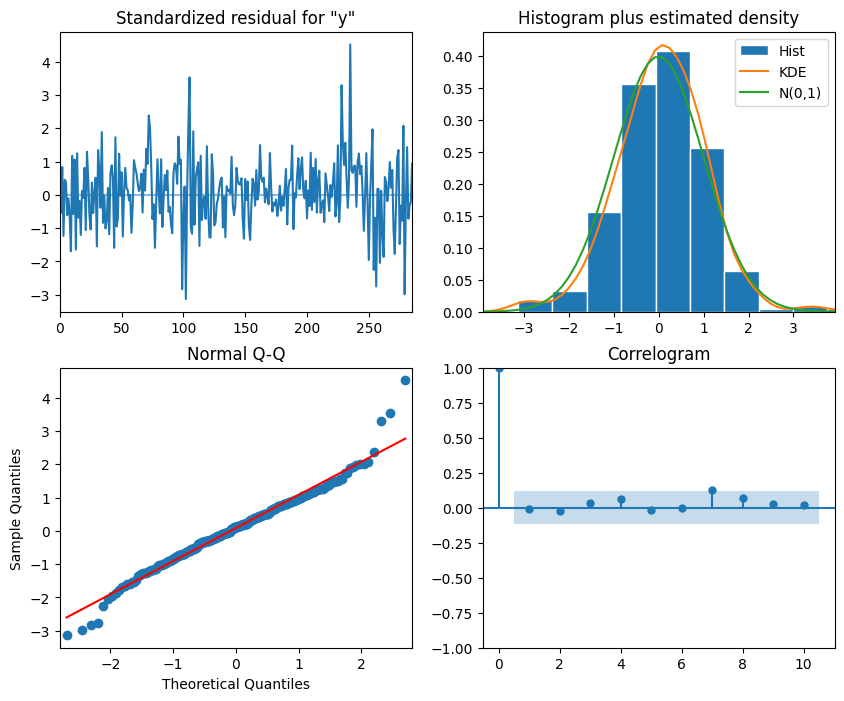

In [33]:
SARIMA_model_fit.plot_diagnostics(figsize=(10,8))

In [34]:
residuals = SARIMA_model_fit.resid

lb_result = acorr_ljungbox(residuals, lags=np.arange(1, 11, 1))

pvalue = lb_result['lb_pvalue'].to_numpy()

print(pvalue)

[0.91237942 0.94893174 0.9704182  0.98581833 0.99621305 0.99902175
 0.99977221 0.99994569 0.99998312 0.99992348]


In [35]:
SARIMA_pred = SARIMA_model_fit.get_prediction(287, 322).predicted_mean

test['SARIMA_pred'] = SARIMA_pred

In [36]:
SARIMA_mae = mean_absolute_error(test['y'], test['SARIMA_pred'])

print(SARIMA_mae)

0.6745632133233112


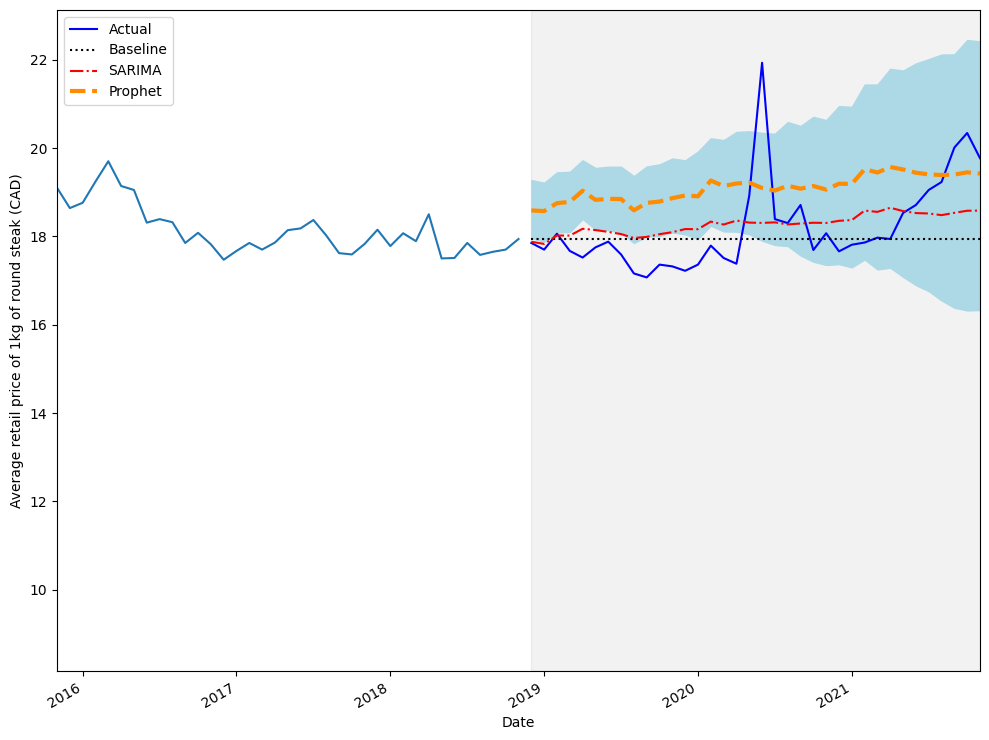

In [37]:
fig, ax = plt.subplots()

ax.plot(train['y'])
ax.plot(test['y'], 'b-', label='Actual')
ax.plot(test['Baseline'], 'k:', label='Baseline')
ax.plot(test['SARIMA_pred'], 'r-.', label='SARIMA')
ax.plot(test['yhat'], color='darkorange', ls='--', lw=3, label='Prophet')

ax.set_xlabel('Date')
ax.set_ylabel('Average retail price of 1kg of round steak (CAD)')

ax.axvspan(287, 322, color='#808080', alpha=0.1)

ax.legend(loc='best')

plt.xticks(np.arange(0, 322, 12), np.arange(1995, 2022, 1))
plt.fill_between(x=test.index, y1=test['yhat_lower'], y2=test['yhat_upper'], color='lightblue')
plt.xlim(250, 322)

fig.autofmt_xdate()
plt.tight_layout()